In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

In [2]:
hdul = fits.open("FORS2.2021-08-21T05_59_05.670.fits") #image
hdul2 = fits.open("Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits") #spectrum
image_data = hdul[0].data
image_data_2 = hdul2[0].data

In [20]:
image_cut = image_data[75:175, 1046:1176]
image_cut_2 = image_data_2[73:173, 0:1800]

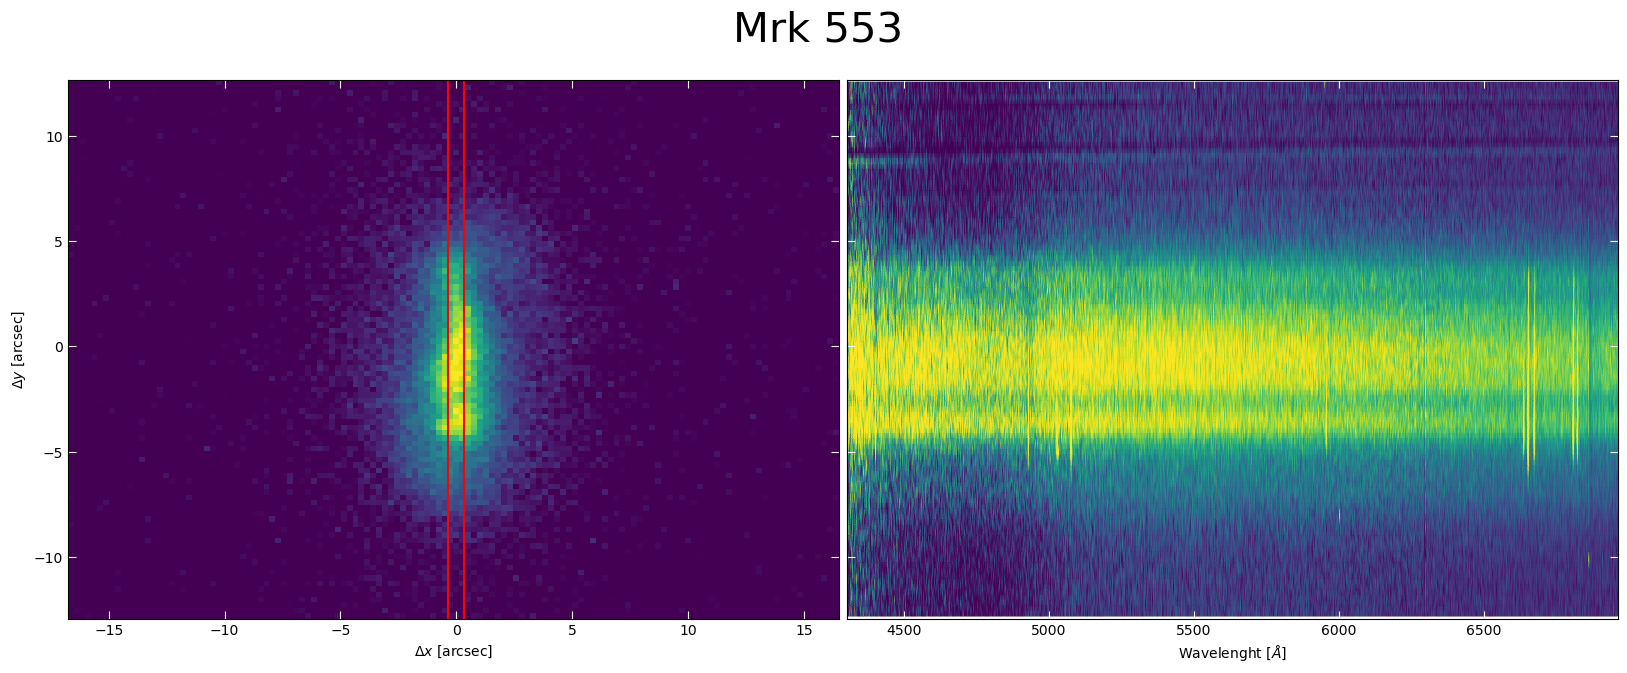

In [21]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
arcsec_x = np.arange(-65*0.256, 65*0.256, 0.256)
arcsec_y = np.arange(-50*0.256, 50*0.256, 0.256)

x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)

x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)

fig, ax = plt.subplots(1,2, figsize=(20, 7), sharey=True)
fig.suptitle('Mrk 553', fontsize=30)

ax[0].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest', vmin=np.log10(2800), vmax=np.log10(4300), cmap = 'viridis') #hot: 2500, 6000
ax[0].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[0].axvline(-0.35, color='red')
ax[0].axvline(0.35, color='red')
ax[0].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)

ax[1].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 5), vmax=np.percentile(image_cut_2, 95)) #altre opzioni
ax[1].set_xlabel(r'Wavelenght [$\AA$]')
ax[1].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)

plt.subplots_adjust(wspace=0.01)
fig.savefig("Galaxy_reduced_spectrum_Mrk553.png")